### Leclair Raphaël / Molines Antoine / Québriac Jeanne

# Introduction

Un ricochet correspond au rebond que fait une pierre lancée à la surface de l'eau. C'est un jeu pratiqué depuis l'antiquité dont le but est que la pierre face le plus de rebonds possiblent à la surface de l'eau et qu'elle aille le plus loin possible. Pour réaliser un ricochet, il y a certaines contraintes telles que la surface de l'eau doit être lisse et la pierre assez plate pour permettre le rebond. Dans le cas contraire, les forces seront orientés dans tous les sens et empêcheront le rebond.

Ici, nous allons essayer de modéliser la trajectoire d'un ricochet et d'analyser l'évolution de ses caractéristiques physiques tout en vérifiant nos résultats avec les records mondiaux. De plus, nous vérifierons que nos codes sont corrects avec des trajectoires simples.

# Problématique: Comment modéliser la trajectoire d'un ricochet pour en étudier les paramètres ?

## Partie 1: La physique

### a) Equations du mouvement

**Bilan des forces:**
* Le poids de la pierre
* La force de traînée et de portance de l'eau et de l'air
* La force de Magnus de l'eau et de l'air
* La poussée d'Archimède

Le **poids** d'un objet est la force gravitationnelle exercée sur celui-ci par la Terre (ou un autre corps céleste).

Forme générale:

$\vec{P}=m \vec{g}$

* $m$ la masse de l'objet ($kg$)
* $g$ l'accélération de pesanteur ($m/s^2$)

La **force de traînée** est la force de résistance exercée par un fluide sur un objet en mouvement à travers ce fluide. Elle s’oppose toujours à la direction du mouvement de l’objet. Ici nous avons deux fluides en mouvement (dans le référentiel du caillou, dans celui de l'observateur ils sont supposés au repos) : l'air pendant toute l'expérience et l'eau lorsque la pierre atteint sa surface.

Forme générale:

$\vec{F}_{trainée} = \frac{1}{2} \, \rho \, C_t \, S \, \vec{v}^2$

* $\rho$ la densité du fluide ($kg/m^3$)
* $C_t$ le coefficient de traînée (sans unité)
* $S$ la surface exposée au fluide ($m^2$)
* $\vec{v}$ la vitesse de l’objet ($m/s$) par rapport au fluide

La **force de portance** est une force générée par un fluide qui s’écoule autour d’un objet, et qui agit perpendiculairement à la direction de l’écoulement du fluide. Elle est dûe à une différence de pression entre les différentes faces de l’objet.

Forme générale:

$\vec{F}_{portance} = \frac{1}{2} \rho C_p S \vec{v}^2 $

* $\rho$ la densité du fluide ($kg/m^3$)
* $C_p$ le coefficient de portance (sans unité)
* $S$ la surface exposée au fluide ($m^2$)
* $\vec{v}$ la vitesse de l’objet ($m/s$) par rapport au fluide

La **force de Magnus** est une force qui agit sur un objet en rotation lorsqu’il se déplace dans un fluide. Elle est perpendiculaire à la direction du mouvement et à l’axe de rotation, et est causée par la différence de vitesse du fluide autour de l’objet dûe à sa rotation.

En effet, lorsque l'objet tourne, d'un côté sa rotation va dans le même sens que l'écoulement du fluide donc accélère le fluide et de l'autre côté de l'objet, la rotation est opposée à l'écoulement et le ralenti. Selon le principe de Bernoulli, une augmentation de la vitesse du fluide entraîne une diminution de la pression, et inversement ce qui entraîne une différence de pression de part et d’autre de l’objet ce qui génère une force latérale entraînant une déviation de la trajectoire initiale de l'objet : c’est la force de Magnus.

Forme générale:

$ \vec{F}_\text{magnus} = \frac{1}{2} \, \rho \, C_M \, S \, R\, \vec{\omega} \times \vec{v}$

* $\rho$ la densité du fluide ($kg/m^3$)
* $C_M$ le coefficient de Magnus (sans unité)
* $S$ la surface projeté perpendiculaire à la direction du mouvement ($m^2$)
* $R$ le rayon de l'objet en rotation ($m$)
* $\vec{\omega}$ la vitesse angulaire ($rad/s$)
* $\vec{v}$ la vitesse de l'objet ($m/s$) par rapport au fluide

La **poussée d'Archimède** nous dit que tout corps plongé dans un fluide subit une poussée verticale, dont on peut placer la résultante sur son centre de gravité. Cette force provient de l'augmentation de la pression du fluide avec la profondeur: la pression étant plus forte sur la partie inférieure d'un objet immergé que sur sa partie supérieure, il en résulte une poussée globalement verticale ascendante. 

Forme générale:

$ \vec{F}_{\text{archimède}}=\rho V \vec{g}$

On négligera sa composante dans l'air dûe à sa masse volumique ~1000 fois plus faible que celle de l'eau.

Nous avons introduit ici trois coefficients, le coefficient de traînée $C_t$, de portance $C_p$ et le coefficient de Magnus $C_M$.

Regardons plus en détail ces coefficients:

Le **coefficient de traînée** est un paramètre sans dimension qui caractérise la résistance d’un objet se déplaçant dans un fluide. Il dépend surtout de la forme de l’objet, de son orientation et du régime d’écoulement caractérisé par le nombre de Reynolds, qui lui dépend notamment de la densité du fluide. On le détermine en général expérimentalement ce qui a conduit à la création de tables listant ces coefficients en fonction des paramètres.

Le **coefficient de portance** est un paramètre sans dimension qui mesure l'efficacité d'un objet à produire de la portance lorsqu’il est plongé dans un fluide en mouvement. Il dépend de la forme de l’objet, de son angle d’attaque, de l’état de l’écoulement qui dépend de la densité du fluide, et parfois de la rotation de l’objet (effet Magnus).

Le **coefficient de Magnus** est un facteur qui décrit l'effet de la rotation d'un objet sur son mouvement dans un fluide. Il mesure l'intensité de la déviation de l'objet (dû à la force de Magnus détaillée plus haut) en fonction de la vitesse de rotation de l'objet, de sa vitesse de déplacement et du fluide environnant.

Comme ces coefficients dépendent du fluide dans lequel circule l'objet, on a un coefficient pour l'air et pour l'eau à chaque fois.

On les obtient à partir de recherches dont les sources sont cités à la fin.

* $C_{t_{eau}}=0.8$
* $C_{t_{air}}= \frac{4}{\sqrt{Re}}$
* $C_{p_{eau}}=1.2$
* $C_{p_{air}}=1.2$

Pour les coefficients de Magnus, ceux-ci sont égaux aux coefficients de traînée ou de portance en fonction de l'orientation et dépendent aussi toujours du milieu dans lequel l'objet se déplace.
* $C_{m_x}=C_t$
* $C_{m_y}=C_t$
* $C_{m_z}=C_p$

On connaît maintenant toutes les forces s'appliquant au caillou ce qui nous permet d'obtenir les **équations du mouvement** en fonction des orientations, et de les résoudre par intégration numérique.

### b) Modèle et hypothèses

Pour simplifier le problème, on considère que l'air et l'eau sont à l'équilibre, c'est à dire qu'il n'y a ni courant de l'air ni de l'eau assez fort pour avoir un impact sur la trajectoire du caillou (la vitesse est beaucoup plus élevée). Cette hypothèse est réaliste en considérant le lancé dans un lac et avec un temps non-venteux. De plus, on modélise le caillou comme un cylindre de rayon $R= 5\ cm$ et de hauteur $h= 5\ mm$ ce qui est cohérent avec les cailloux plat que nous pouvons trouver dans la nature. Enfin, le cylindre sera définit comme du quartz de masse volumique $\rho_{quartz}= 2650\ kg/m^3$, un type de roche commune au bord des lacs.

Une fois toutes les données techniques récupérées, il est important de définir les conditions initiales associées au cylindre.

On est dans la situation d'un solide en mouvement donc celui-ci est décrit par son orientation décomposée en 3 angles,
* L'angle $\theta$ entre la surface de l'eau et le côté disque du cylindre 
* L'angle $\phi$ de basculement de l'angle
* L'angle $\psi$ de rotation du cylindre sur lui-même

et par sa position définit par le système de coordonnées $(Oxyz)$.

Pour trouver ces valeurs à l'état initial, on se réfère à la vidéo du record mondial du ricochet réalisé en 2013 ainsi que l'article cité à la fin:

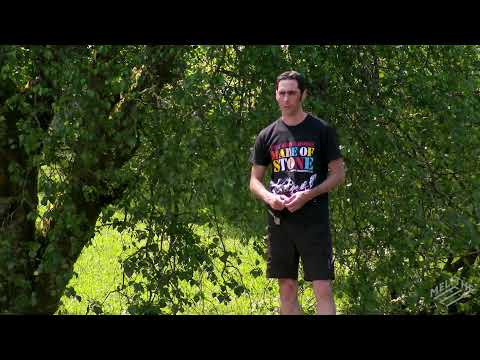

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("kOT19pRZ5rE", width=800, height=450)

On définit l'origine du repère $(Oxyz)$ sous les pieds de l'homme qui effectue le lancé à la surface de l'eau donc:
* $x_0= 0\ m$
* $y_0= 0\ m$
* $z_0= 1,5\ m$

Pour l'angle d'inclinaison du lancé, on se réfère à ce que dit l'article $\theta_0= 20°$ et pour les autres angles on les définit par logique nulle à l'état initial donc $\phi_0= 0°$ et $\psi_0=0°$

La position et l'orientation du solide sont maintenant définit à l'état initial mais il nous faut maintenant les vitesses associées à tous ces paramètres pour obtenir la trajectoire du caillou.

Pour cela, on se réfère à l'article:

Il est indiqué que la **vitesse de translation initiale** du caillou est de 43 mph soit $v = 19.22\ m/s$ or le caillou a une vitesse initiale selon $x$ et selon $z$. On déduit grossièrement grâce à la vidéo que la vitesse selon x et beaucoup plus grande que celle selon z donc on choisit $v_{0x}= 17.22\ m/s$ et $v_{0z}= -2\ m/s$, sans oublier de définir $v_{0y}=0\ m/s$.

Du côté de la **vitesse de rotation initiale** du caillou on lit que le caillou tourne sur lui même à 2200 rpm soit $v_{\psi0}= 232\ rad/s$. On définit les autres vitesses de rotation nulles à l'état initial par logique donc $v_{\theta0}=0\ rad/s$ et $v_{\phi0}=0\ rad/s$.


De plus, un autre paramètre essentiel pour la construction de notre modèle est le **coefficient de restitution** entre le caillou et l'eau, définit comme le rapport entre la vitesse avant un rebond et celle après: $$e=\frac{v_{i+1}}{v_i}$$
D'après la conservation de l'énergie, on a $v^2=2gH$ (H la hauteur du rebond), et donc un calcul direct donne: $$e=\sqrt{\frac{H_{i+1}}{H_i}}$$ Visuellement, on peut estimer le rapport de hauteur avant et après un rebond d'envirion 0.5 -ce qui donne environ $e=0.7$- nous utiliserons donc cette valeur pour notre modèle (même si l'énergie n'est pas conservée).

## Partie 2: Visualisation de la trajectoire d'un ricochet

### a) Importation des bibliothèques

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### b) Paramètres physiques
Ici, nous définissons les paramètres constants de notre modèle:

In [3]:
R = 0.05 # rayon du cylindre en m
h=0.005 # hauteur du cylindre en m
g = 9.81 # m/s^2

S_d = np.pi * R**2 # surface du disque en m^2
S_front=R*h # surface frontale du cylindre en m^2

rho_caillou=2650 # kg/m^3

m = rho_caillou*S_d*h # kg

rho_air = 1.225 # kg/m^3
rho_eau=1e3 # kg/m^3

#Coefficient de traînée
Ct_eau = 0.8

#Coefficients de portance
Cp_air = 1.2
Cp_eau = 1.2

#Moment d'inertie
I = 0.5 * m * R**2 # kg.m^2

On a introduit ici le **moment d'inertie** d'un disque uniforme. C'est une grandeur physique qui mesure la résistance d’un objet à la mise en rotation autour d’un axe. Elle nous servira à calculer l'énergie cinétique de rotation.

Forme générale:
$$
I=\int_{volume} r^2 \, dm
$$
* $r$ le rayon de rotation de l'élément de masse $dm$

En résolvant cette intégrale, on obtient:
$$
I=\frac{1}{2} M R^2
$$
* $R$ le rayon du cylindre
* $M$ la masse du cylindre

### c) Equations du mouvement

On a maintenant toutes les données nécessaires pour modéliser la trajectoire de notre ricochet.

On créer pour cela une fonction dissociant le moment où le galet est dans l'eau ou dans l'air. Que ce soit dans l'air ou dans l'eau toutes les forces cités plus haut sont appliquées sauf pour la poussée d'Archimède rajoutée dans la force de portance qui n'est appliquée que pour l'eau. Pour celle-ci, on dissocie deux cas, celui où le cylindre est totalement immergé et celui où seulement une partie du cylindre est immergé.

In [4]:
def gallet_dynamique(t, state, v_max): #v_max est un garde fou sur la vitesse
    x, y, z, dx, dy, dz, phi, theta, psi, dphi, dtheta, dpsi = state #dx, dy et dz sont les composantes de la vitesse
                                                                     #dphi, dtheta, dpsi sont les composantes de la vitesse angulaire
    dx=np.clip(dx,-v_max,v_max)
    dy=np.clip(dy,-v_max,v_max)
    dz=np.clip(dz,-v_max,v_max)
    
    v=np.sqrt(dx**2 + dy**2 + dz**2)
    wx, wy, wz = dphi, dtheta, dpsi #phi est l'angle de rotation autour de (Ox)
                                    #theta est l'angle entre le gallet et l'eau, celui de rotation autour de (Oy)
                                    #psi est l'angle de rotation propre, autour de (Oz)
    
    if z > h/2: #Si l'on est dans l'air, z représente l'altitude du centre du cylindre
        nu_air=15.6e-6 #viscosité cinématique de l'air à 25°C
        Re=R*v/nu_air
        
        Ct_air=4/np.sqrt(Re) #Approximation du coefficient de traînée
        
        Fx_trainee = -0.5 * rho_air * Ct_air * (S_d*np.sin(theta)+S_front*np.cos(theta)) * v*dx
        Fy_trainee = -0.5 * rho_air * Ct_air * (S_d*np.sin(phi)+S_front*np.cos(phi)) * v*dy
        Fz_trainee = -0.5 * rho_air * Ct_air * (S_d*np.cos(theta)+S_front*np.sin(theta)) * v*dz
        Fz_portee = 0.5 * rho_air * Cp_air * (S_d*np.cos(theta)+S_front*np.sin(theta)) * v**2
        
        Fx_magnus = 0.5 * rho_air * S_d * R * Ct_air * (wy * dz - wz * dy)
        Fy_magnus = 0.5 * rho_air * S_d * R * Ct_air * (wz * dx - wx * dz)
        Fz_magnus = 0.5 * rho_air * S_d * R * Cp_air * (wx * dy - wy * dx)
        
        #gardes fous choisi en testant différentes valeurs
        Fz_portee = np.clip(Fz_portee, -0.85 * m * g, 0.85 * m *g)
        Fz_magnus = np.clip(Fz_magnus, -0.2 * m * g, 0.2 * m *g)
        
       
    if z <= h/2: #Si on est sur ou dans l'eau
        Fx_trainee = -0.5 * rho_eau * Ct_eau * (S_d*np.cos(theta)+S_front*np.sin(theta)) * v*dx
        Fy_trainee = -0.5 * rho_eau * Ct_eau * (S_d*np.cos(phi)+S_front*np.sin(phi)) * v*dy
        Fz_trainee = -0.5 * rho_eau * Ct_eau * (S_d*np.sin(phi)+S_front*np.cos(phi)) * v*dz
        Fz_portee = 0.5 * rho_eau * Cp_eau * (S_d*np.sin(phi)+S_front*np.cos(phi)) * v**2
        
        #On rajoute la poussée d'Archimède non-négligeable dans l'eau
        if z > -h/2:
            V = S_d*abs(z)
            Fz_portee += rho_eau*V*g
        elif z <= -h/2:
            V = S_d*h
            Fz_portee += rho_eau*V*g
            
        Fx_magnus = 0.5 * rho_eau * S_d * R * Ct_eau * (wy * dz - wz * dy)
        Fy_magnus = 0.5 * rho_eau * S_d * R * Ct_eau * (wz * dx - wx * dz)
        Fz_magnus = 0.5 * rho_eau * S_d * R * Cp_eau * (wx * dy - wy * dx)
    
    #Principe Fondamental de la Dynamique
    ddx = (Fx_trainee + Fx_magnus) / m
    ddy = (Fy_trainee + Fy_magnus) / m
    ddz = (Fz_magnus + Fz_portee - m * g) / m
    
    ddphi = 0
    ddtheta = 0
    ddpsi = 0
    
    return np.array([dx, dy, dz, ddx, ddy, ddz, dphi, dtheta, dpsi, ddphi, ddtheta, ddpsi])

On a du poser des limites pour la vitesse et la force de traînée et de Magnus selon z car notre modèle n'intègre pas certaines limites, comme par exemple quand la pierre s'arrête en touchant le fond du lac ce qui provoque des valeurs infinis qui ne correspondent pas à la réalité. Aussi, nous avons fait cela pour éviter des calculs qui divergent dûs à des valeurs trop élevées.

### d) Résolution des équations du mouvement

La fonction **gallet_dynamique** renvoie un vecteur avec les vitesses et accélérations, en connaissant les positions et vitesses initiales de chaques variables, on obtient une suite récurente de systèmes d'équations différentielles du premier ordre, par exemple:
$$
\dfrac{\mathrm{d} v}{\mathrm{d}t}=C^{ste}v \\
\dfrac{\mathrm{d} x}{\mathrm{d}t}=v
$$
On peut alors utiliser la méthode Runge-Kutta d'ordre 4 pour résoudre les équations du mouvement:

In [5]:
def simul(dynamique, state0, t, restitution=0.70): #dynamique est la fonction à intégrer, ici ça sera gallet_dynamique
    n = len(t)
    state = np.zeros((n, len(state0)))
    state[0] = state0.copy()
    v_max=np.sqrt(state[0][3]**2 + state[0][4]**2 + state[0][5]**2)+10 #On prend la vitesse initiale comme garde fou (v_max=np.sqrt(dx0**2 + dy0**2 + dz0**2))
    
    for i in range(n - 1):
        dt = t[i+1] - t[i]
        k1 = dynamique(t[i], state[i], v_max)
        k2 = dynamique(t[i] + dt/2, state[i] + dt/2 * k1, v_max)
        k3 = dynamique(t[i] + dt/2, state[i] + dt/2 * k2, v_max)
        k4 = dynamique(t[i] + dt, state[i] + dt * k3, v_max)
        state_next = state[i] + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
        if state[i][2] > h/2 and state_next[2] <= h/2 and state[i][5] < 0: #Quand à l'instant i on est dans l'air et à l'instant i+1 sur l'eau
            
            state_next[5]=-restitution*state[i][5]#il faut prendre en compte les pertes d'énergie et de vitesse dûes aux rebonds instantanés
                                                  #qui sont autres que celles dûes aux forces aérodynamiques
            
        state[i+1] = state_next
        
    return state

Nous avons donc les deux fonctions nécessaires pour simuler la trajectoire du gallet, il nous manque plus qu'à coder les conditions initales, qui sont les différentes conditions de lancé du gallet. Ces conditions vont nous servir à étudier plusieurs cas. Pour l'instant, nous utilisons les conditions issues du record du monde discuté plus haut.

In [6]:
# Conditions initiales

x0, y0, z0 = 0, 0, 1.5 #m
dx0, dy0, dz0 = 17.22, 0, -2 #m/s
phi0, theta0, psi0 = 0, 20*np.pi/180, 0 #rad
dphi0, dtheta0, dpsi0 = 0, 0, 230 #rad.s^{-1}
initial_state = [x0, y0, z0, dx0, dy0, dz0, phi0, theta0, psi0, dphi0, dtheta0, dpsi0]
t_values = np.linspace(0, 9.5, int(4e4)) #s

Nous pouvons donc associer ces conditions initiales aux fonctions définit plus haut et en profiter pour calculer les paramètres dont nous allons étudier l'évolution:

In [7]:
#Simulation

sim_ricochets = simul(gallet_dynamique, initial_state, t_values)
x, y, z = sim_ricochets[:, 0], sim_ricochets[:, 1], sim_ricochets[:, 2]
dx, dy, dz = sim_ricochets[:, 3], sim_ricochets[:, 4], sim_ricochets[:, 5]
dphi, dtheta, dpsi = sim_ricochets[:, 9], sim_ricochets[:, 10], sim_ricochets[:, 11]
cin_trans = 0.5 * m * (dx**2 + dy**2 + dz**2) #J
cin_rot = 0.5 * I * (dtheta**2 + dphi**2 + dpsi**2) #J
E_pot = m * g * z #J
E_totale = cin_trans + cin_rot + E_pot #J

### e) Trajectoire du ricochet 
Traçons alors la trajectoire que donne la simulation:

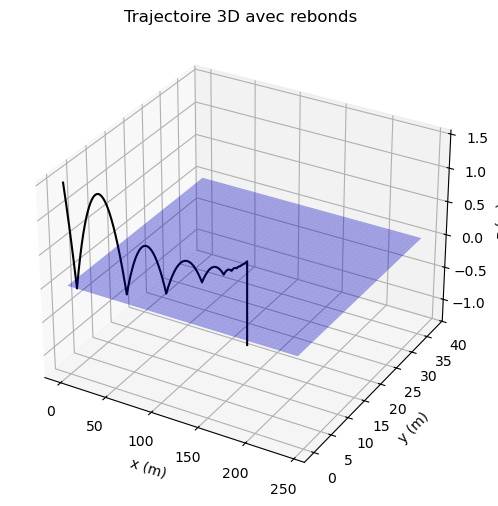

In [8]:
# Visualisation
fig = plt.figure(figsize=(14, 6))

# Trajectoire et plan bleu
ax1 = fig.add_subplot(121, projection='3d')

# Plot de la trajectoire
ax1.plot(x, y, z, color='black')

# Equation du plan bleu
x_plane = np.linspace(min(x)/2, max(x)*2, 100)
y_plane = np.linspace(min(y)/2, max(y)*2, 100)
x_plane, y_plane = np.meshgrid(x_plane, y_plane)
z_plane = 0 * np.ones_like(x_plane)

# Plot du plan, alpha défini la transparence
ax1.plot_surface(x_plane, y_plane, z_plane, color='blue', alpha=0.35)

ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")
ax1.set_zlabel("z (m)")
ax1.set_title("Trajectoire 3D avec rebonds")
plt.show()

On observe bien ici la trajectoire d'un ricochet: les rebonds s'enchaînent et leur hauteur diminue jusqu'à ce que le caillou coule dans l'eau.

On peut vérifier ici que notre modèle est correct en comparant la distance maximale parcourue par notre caillou avec celle du record mondial d'où nous avons tiré les propriétés du lancé.

On a:

In [9]:
print("x_max= ",round(np.max(x),1),"m")

x_max=  121.6 m


D'après la vidéo et les articles, lors du record mondial, le caillou est allé jusqu'à 121.8 m et à 121.6 m avec notre modèle, l'écart est extrêmement faible. On peut considérer que notre modèle a bien réussi à reproduire le lancé de la vidéo en lui ayant donné les mêmes conditions initiales.

Regardons maintenant la trajectoire du ricochet vue de haut donc dans le plan **(0xy)**.

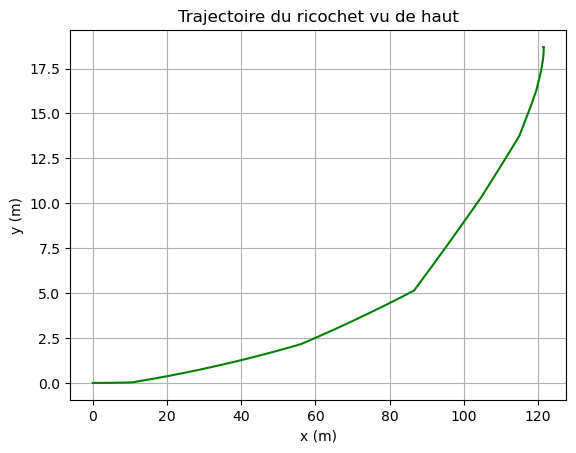

In [10]:
plt.plot(x,y, color='green')
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Trajectoire du ricochet vu de haut")
plt.grid()
plt.show()

On observe bien une trajectoire courbée dans le plan $(Oxy)$ comme attendue avec à l'effet Magnus.\
On peux remarquer que la trajectoire n'est pas réellement courbée mais semble plutôt effectuer des virages vers les $y$ positifs par incréments,\
cela vient du fait que l'effet Magnus n'est veritablement non-négligeable que dans l'eau, les virages correspondent donc au ricochets (on peut voir \
que, à la fin quand le caillou fait beaucoup de rebonds avec peu d'écart de temps, la trajectoire paraît beaucoup plus courbée).

## Partie 3: Evolution des paramètres

Nous avons pu visualiser la trajectoire du ricochet mais il est aussi intéressant d'analyser l'évolution de ses paramètres, ce que nous allons faire maintenant.

### a) Energie

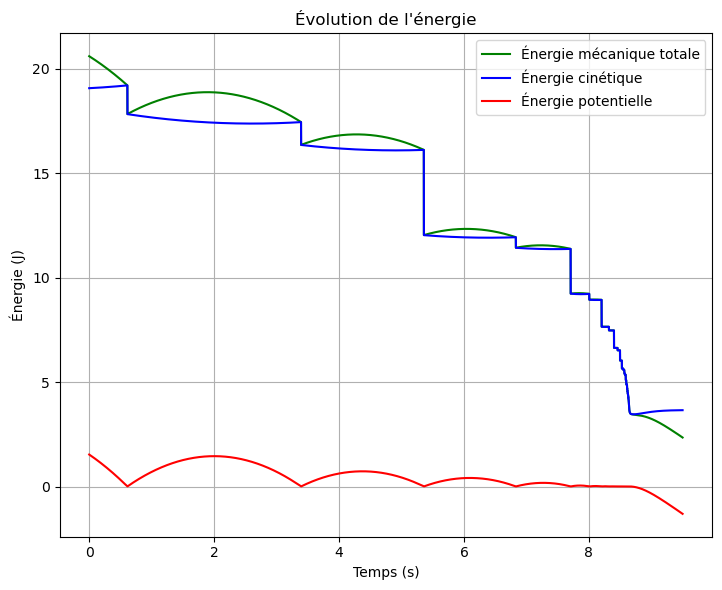

In [11]:
fig = plt.figure(figsize=(14, 6))
ax2 = fig.add_subplot(122)
ax2.plot(t_values, E_totale, label="Énergie mécanique totale", color='green')
ax2.plot(t_values, cin_trans + cin_rot, label="Énergie cinétique", color='blue')
ax2.plot(t_values, E_pot, label="Énergie potentielle", color='red')
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Énergie (J)")
ax2.set_title("Évolution de l'énergie")
ax2.grid()
ax2.legend()
plt.tight_layout()
plt.show()

L'**énergie potentielle** à la même allure que la hauteur du caillou (bosses puis chute) ce qui est cohérent avec son expression: $E_{pot}=mgz$.

L'**énergie cinétique** décroît de manière régulière puis de manière chaotique à partir du moment où le caillou ne rebondit presque plus car à ce moment, les bonds sont très petits. De plus, on peut remarquer qu'à chaque impact avec l'eau, l'énergie cinétique chute brusquement dû au coefficient de restitution qui diminue la vitesse. On peut le justifier plus simplement se rappelant qu'à chaque rebond la vitesse change d'orientation ce qui est coûteux en énergie. Finalement cette énergie se stabilise vers 3.5J quand le caillou est dans l'eau.

L'**énergie mécanique** est conservée au cours d'un rebond mais pas au cours de toute la trajectoire car nous n'avons pas modélisé le sol sous l'eau, ce qui entraine une divergence non-physique dans l'altitude du caillou (qui tombe infiniment), et donc également de l'énergie.

### b) Altitude

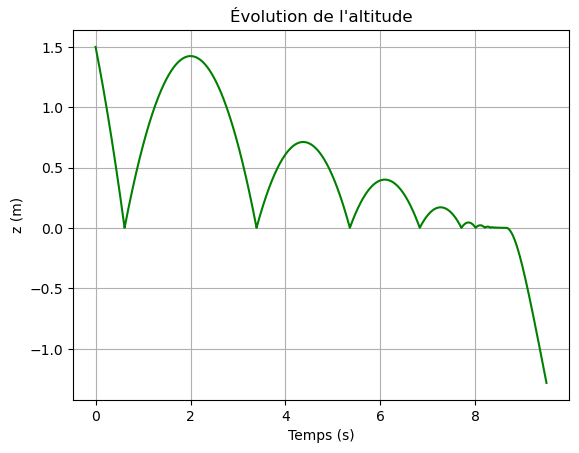

In [12]:
plt.plot(t_values,z, color='green')
plt.xlabel("Temps (s)")
plt.ylabel("z (m)")
plt.title("Évolution de l'altitude")
plt.grid()
plt.show()

Grâce à ce graphe, on observe plus simplement les rebonds et leur hauteur qui diminue. On observe ici également la divergence de l'altitude liée à notre modèle.

## Partie 4: Vérification des cas particuliers
Pour vérifier que notre code marche, et que notre modèle rend vraiment compte de la réalité et n'est pas juste un "coup de chance", nous allons le tester dans des cas simples où nous connaissons les résultats théoriques attendus.
### a) Chute Libre
Regardonc par exemple, si notre code arrive à modéliser une simple chute libre. Pour cela, fixons les vitesses initiales à zero : $v_0=0 m/s$, et pareil pour les vitesse de rotations initiales $\dot{\psi}=0 $rad/s. Fixons l'altitude initiale à : $z_0=10m$. Nous fixons également le coefficient de restitution à zero ici, car nous ne voulons pas modéliser de rebonds.

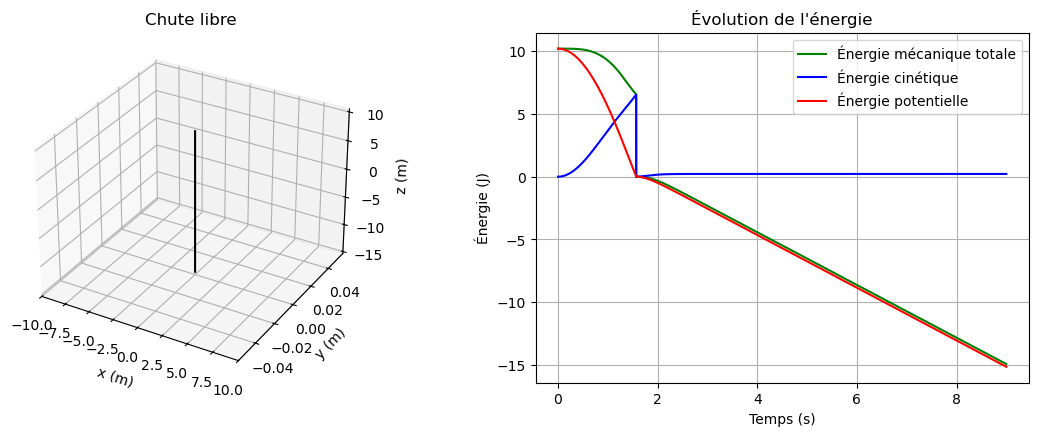

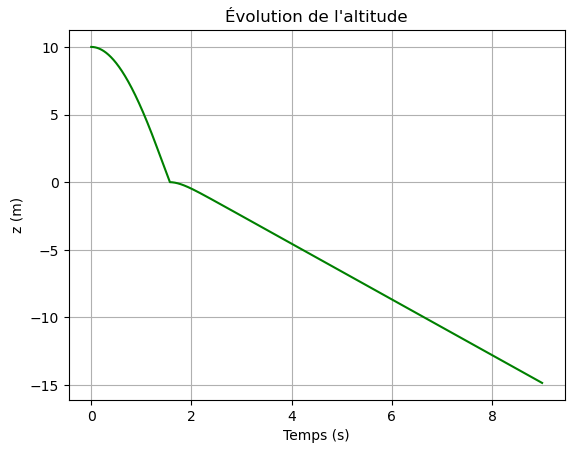

In [13]:
# Conditions initiales

x0, y0, z0 = 0, 0, 10 #m
dx0, dy0, dz0 = 0.0001, 0, 0 #m/s
phi0, theta0, psi0 = 0, 20*np.pi/180, 0 #rad
dphi0, dtheta0, dpsi0 = 0, 0, 0 #rad.s^{-1}
initial_state = [x0, y0, z0, dx0, dy0, dz0, phi0, theta0, psi0, dphi0, dtheta0, dpsi0]
t_values = np.linspace(0, 9, int(3e4)) #s

sim_ricochets = simul(gallet_dynamique, initial_state, t_values,0)
x, y, z = sim_ricochets[:, 0], sim_ricochets[:, 1], sim_ricochets[:, 2]
dx, dy, dz = sim_ricochets[:, 3], sim_ricochets[:, 4], sim_ricochets[:, 5]
dphi, dtheta, dpsi = sim_ricochets[:, 9], sim_ricochets[:, 10], sim_ricochets[:, 11]
cin_trans = 0.5 * m * (dx**2 + dy**2 + dz**2) #J
cin_rot = 0.5 * I * (dtheta**2 + dphi**2 + dpsi**2) #J
E_pot = m * g * z #J
E_totale = cin_trans + cin_rot + E_pot #J

# Visualisation
fig = plt.figure(figsize=(14, 10))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot(x, y, z, color='black')

x_plane = np.linspace(min(x)/2, max(x)*2, 100)
y_plane = np.linspace(min(y)/2, max(y)*2, 100)
x_plane, y_plane = np.meshgrid(x_plane, y_plane)
z_plane = 0 * np.ones_like(x_plane)
ax1.plot_surface(x_plane, y_plane, z_plane, color='blue', alpha=0.35)
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")
ax1.set_zlabel("z (m)")
ax1.set_title("Chute libre")
ax1.set_xlim(-10,10)

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(t_values, E_totale, label="Énergie mécanique totale", color='green')
ax2.plot(t_values, cin_trans + cin_rot, label="Énergie cinétique", color='blue')
ax2.plot(t_values, E_pot, label="Énergie potentielle", color='red')
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Énergie (J)")
ax2.set_title("Évolution de l'énergie")
ax2.grid()
ax2.legend()
plt.show()
plt.plot(t_values,z, color='green')
plt.xlabel("Temps (s)")
plt.ylabel("z (m)")
plt.title("Évolution de l'altitude")
plt.grid()
plt.show()

Ces résultats sont assez convaincants, en effet la **trajectoire 3D** montre bien une droite, la trajectoire d'une chute libre. Aussi, le **graphe de l'altitude en fonction du temps** montre bien une évolution en deux temps: premièrement une évolution parabolique, comptatible avec la théorie $z(t)=-\frac{gt^2}{2}$, puis dans un deuxième temps une évolution linéaire, ce qui indique que les forces de frottements de l'eau compensent le poid du galet: il a atteint sa vitesse terminale.\
\
D'un **point de vu énergitique**, on observe dans le premier temps une augmentation de l'énergie cinétique cohérente avec l'évolution de la vitesse, qui est dans un second temps stoppée brutallement quand le caillou entre dans l'eau. Ensuite l'energie semble être nulle sur le graphe, mais est en vérité constante (due à la vitesse terminale dans l'eau), un tout petit peu au dessus de zero. On ne le voit pas car le graphe n'est pas assez centré.\
L'énergie potentielle diminue quand l'energie cinétique augmente, puis diminue "infiniment", car nous n'avons pas modélisé un sol dans l'eau où le caillou s'arréterait.

### b) Mouvement parabolique
Rajoutons une vitesse initiale de la forme $v_x=v_z=10m/s$, pour vérifier si notre modèle marcherait pour un mouvement parabolique simple. Nous fixons l'altitude initiale $z_0=0$.

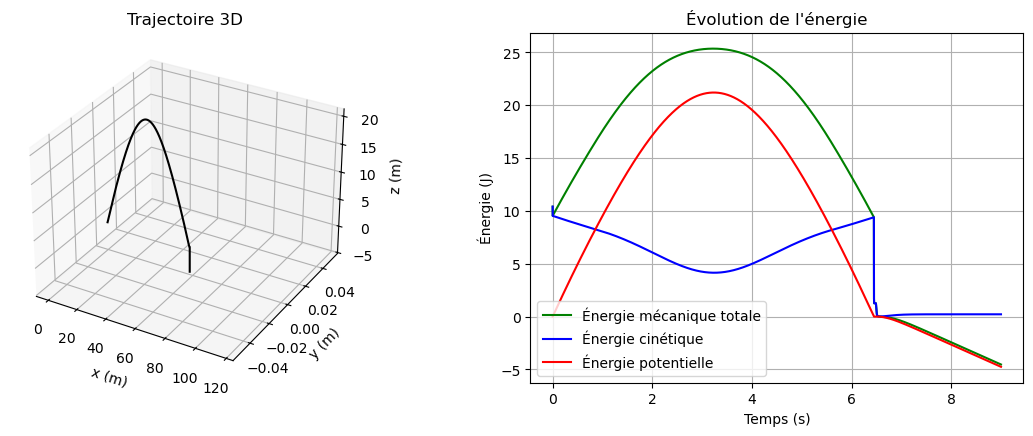

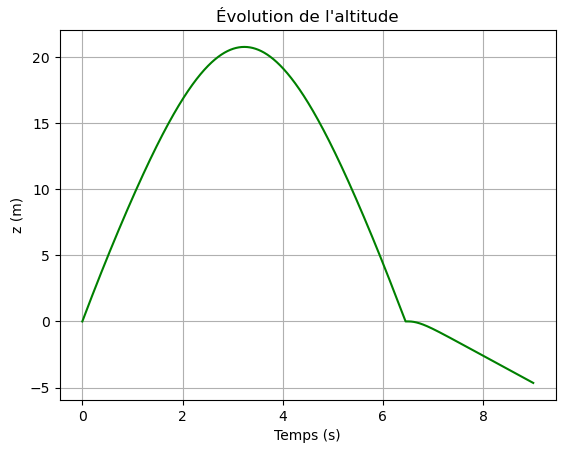

In [14]:
# Conditions initiales

x0, y0, z0 = 0, 0, 0 #m
dx0, dy0, dz0 = 10, 0, 10 #m/s
phi0, theta0, psi0 = 0, 20*np.pi/180, 0 #rad
dphi0, dtheta0, dpsi0 = 0, 0, 0 #rad.s^{-1}
initial_state = [x0, y0, z0, dx0, dy0, dz0, phi0, theta0, psi0, dphi0, dtheta0, dpsi0]
t_values = np.linspace(0, 9, int(3e4)) #s

sim_ricochets = simul(gallet_dynamique, initial_state, t_values,0)
x, y, z = sim_ricochets[:, 0], sim_ricochets[:, 1], sim_ricochets[:, 2]
dx, dy, dz = sim_ricochets[:, 3], sim_ricochets[:, 4], sim_ricochets[:, 5]
dphi, dtheta, dpsi = sim_ricochets[:, 9], sim_ricochets[:, 10], sim_ricochets[:, 11]
cin_trans = 0.5 * m * (dx**2 + dy**2 + dz**2) #J
cin_rot = 0.5 * I * (dtheta**2 + dphi**2 + dpsi**2) #J
E_pot = m * g * z #J
E_totale = cin_trans + cin_rot + E_pot #J

# Visualisation
fig = plt.figure(figsize=(14, 10))

# Haut gauche : Trajectoire 3D
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot(x, y, z, color='black')
x_plane = np.linspace(min(x)/2, max(x)*2, 100)
y_plane = np.linspace(min(y)/2, max(y)*2, 100)
x_plane, y_plane = np.meshgrid(x_plane, y_plane)
z_plane = 0 * np.ones_like(x_plane)
ax1.plot_surface(x_plane, y_plane, z_plane, color='blue', alpha=0.35)
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")
ax1.set_zlabel("z (m)")
ax1.set_title("Trajectoire 3D")

# Haut droite : Énergies
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(t_values, E_totale, label="Énergie mécanique totale", color='green')
ax2.plot(t_values, cin_trans + cin_rot, label="Énergie cinétique", color='blue')
ax2.plot(t_values, E_pot, label="Énergie potentielle", color='red')
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Énergie (J)")
ax2.set_title("Évolution de l'énergie")
ax2.grid()
ax2.legend()
plt.show()
plt.plot(t_values,z, color='green')
plt.xlabel("Temps (s)")
plt.ylabel("z (m)")
plt.title("Évolution de l'altitude")
plt.grid()
plt.show()

Nous observons bien une **trajectoire** de forme parabolique plane d'équation $x(t)=v_0\cos(\theta)t$ et $z(t)=v_0\sin(\theta)t-gt^2/2$, suivi d'une chute libre. Le **graphe de l'énergie** est le même que pour celui de la chute libre, à l'exception de la phase ascendente de la trajectoire. L'**évolution de l'altitude en fonction du temps** est aussi la même: on observe bien les deux phases de la trajectoire: dans l'air et dans l'eau, avec la vitesse terminale dans l'eau.

### c) Rebonds sans effet Magnus

Essayons maintenant de modéliser une trajectoire avec rebonds, sans prendre un compte de l'effet Magnus. Pour cela, nous fixons la vitesse de rotation intiale $\dot{\psi}=0 rad/s$.

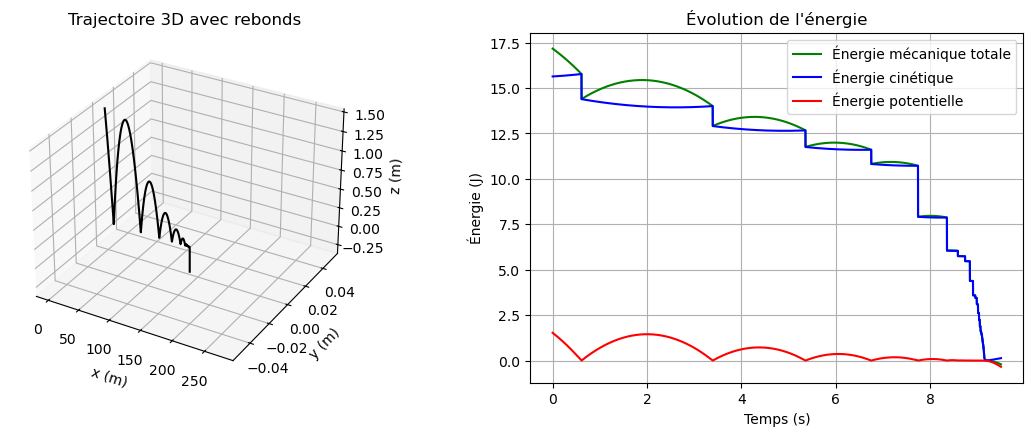

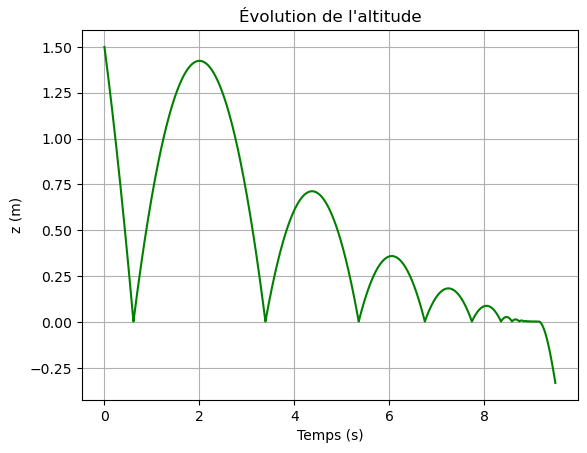

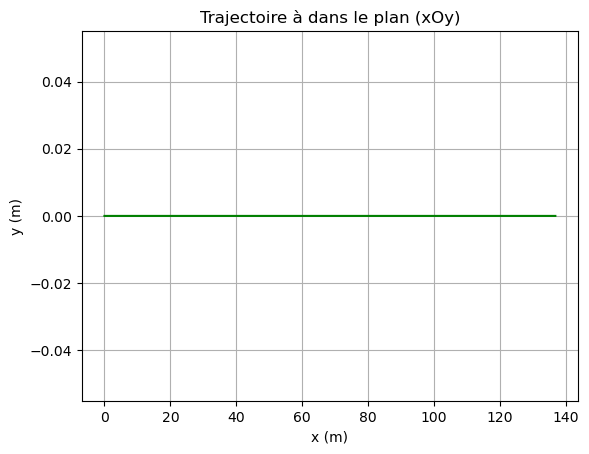

In [15]:
# Conditions initiales
x0, y0, z0 = 0, 0, 1.5 #m
dx0, dy0, dz0 = 17.22, 0, -2 #m/s
phi0, theta0, psi0 = 0, 20*np.pi/180, 0 #rad
dphi0, dtheta0, dpsi0 = 0, 0, 0 #rad.s^{-1}
initial_state = [x0, y0, z0, dx0, dy0, dz0, phi0, theta0, psi0, dphi0, dtheta0, dpsi0]
t_values = np.linspace(0, 9.5, int(4e4)) #s

sim_ricochets = simul(gallet_dynamique, initial_state, t_values,0.7)
x, y, z = sim_ricochets[:, 0], sim_ricochets[:, 1], sim_ricochets[:, 2]
dx, dy, dz = sim_ricochets[:, 3], sim_ricochets[:, 4], sim_ricochets[:, 5]
dphi, dtheta, dpsi = sim_ricochets[:, 9], sim_ricochets[:, 10], sim_ricochets[:, 11]
cin_trans = 0.5 * m * (dx**2 + dy**2 + dz**2) #J
cin_rot = 0.5 * I * (dtheta**2 + dphi**2 + dpsi**2) #J
E_pot = m * g * z #J
E_totale = cin_trans + cin_rot + E_pot #J

# Visualisation
fig = plt.figure(figsize=(14, 10))

# Haut gauche : Trajectoire 3D
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot(x, y, z, color='black')
x_plane = np.linspace(min(x)/2, max(x)*2, 100)
y_plane = np.linspace(min(y)/2, max(y)*2, 100)
x_plane, y_plane = np.meshgrid(x_plane, y_plane)
z_plane = 0 * np.ones_like(x_plane)
ax1.plot_surface(x_plane, y_plane, z_plane, color='blue', alpha=0.35)
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")
ax1.set_zlabel("z (m)")
ax1.set_title("Trajectoire 3D avec rebonds")

# Haut droite : Énergies
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(t_values, E_totale, label="Énergie mécanique totale", color='green')
ax2.plot(t_values, cin_trans + cin_rot, label="Énergie cinétique", color='blue')
ax2.plot(t_values, E_pot, label="Énergie potentielle", color='red')
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Énergie (J)")
ax2.set_title("Évolution de l'énergie")
ax2.grid()
ax2.legend()
plt.show()
plt.plot(t_values,z, color='green')
plt.xlabel("Temps (s)")
plt.ylabel("z (m)")
plt.title("Évolution de l'altitude")
plt.grid()
plt.show()
plt.plot(x,y, color='green')
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Trajectoire à dans le plan (xOy)")
plt.grid()
plt.show()

Nous observons ainsi bien une **trajectoire** uniquement selon x (on a tracé la projection sur le plan Oxy pour s'en convaincre) comme attendu: il n'y a pas de vitesse de rotation, donc pas de courbure de la trajectoire liée à l'effet Magnus contrairement à ce que nous avons pu observer dans la partie 2.

De plus, on peut voir que le graphe de **"l'évolution de l'énergie"** est similaire à celui où l'on prend en compte l'effet Magnus mais on remarque que la perte d'énergie mécanique est plus lente. Cela vient du fait qu'il n'y a pas de transfert entre les énergies de rotation et de translation donc moins de pertes d'énergie et donc plus d'énergie pour le ricochet. Cela donne donc une distance parcourue plus longue et un nombre de rebonds plus élevé. On le vérifie graphiquement en comparant les graphes de **l'altitude** et de la **trajectoire à 2D** sans effet Magnus avec ceux incluant cet effet: sans effet Magnus il y a encore des rebonds significatifs au bout de 8 secondes et on voit qu'avec la même durée totale de simulation, sans effet Magnus le caillou dépasse les 121.6m parcourus.

## Conclusion

Le test de notre modèle sur des cas simples a permis de vérifier à quel point ce modèle rend compte de la réalité. En effet, les différentes trajectoires du ricochet modélisé obtenues en faisant varier certains paramètres spécifiques sont toujours en accord avec la théorie et les lois de la mécanique du solide et des fluides. De plus, en mettant les mêmes paramètres que ceux issus du record du monde, nous obtenons des résultats similaires, notamment en terme de distance. En revanche, notre modèle possède quelques limites. En effet, nous n'avons pas modélisé le sol, ce qui entraîne une trajectoire infinie et donc une divergence non-physique de l'énergie potentielle. Aussi, notre modèle rend compte d'un ricochet dans des conditions parfaites, où l'on considère que la surface de l'eau est parfaitement plane, et où l'on oublie le vent, ce qui est rarement le cas. De plus, la valeur du coefficient de restitution est définit comme constante ce qui est une forte approximation. En réalité, la nature des matériaux et de la surface (ex: balle en caoutchouc, vague sur l'eau) ont pour effet de faire varier ce coefficient. Mais dans le cadre de notre étude, basé sur la physique du solide, cette approximation est relativement cohérente.

## **Références**

Coefficient de trainée (dans le pdf non accessible maintenant) et de portance de l'eau : \
https://ntrs.nasa.gov/citations/19840015538 \
\
Coefficient portance de air (tableau du coefficient en fonction de l'angle d'incidence) :\
https://eaglepubs.erau.edu/introductiontoaerospaceflightvehicles/chapter/airfoil-characteristics/ \
\
Coefficient de traînée de l'air (formule page 9) :\
https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://apps.dtic.mil/sti/tr/pdf/ADA395503.pdf&ved=2ahUKEwiBvYDBv8qMAxWPTaQEHVE_KsIQFnoECBsQAQ&usg=AOvVaw33kLumyZ88LDeibBn1Sy6U \
\
Viscosité cinématique (tableau):\
https://fr.wikipedia.org/wiki/Viscosit%C3%A9_cin%C3%A9matique \
\
Masse volumique du quartz :\
https://la-liste.fr/science/physique/proprietes-physico-chimiques-des-materiaux/les-masses-volumiques-des-roches-et-des-materiaux \
\
Rock skimming world record :\
https://www.youtube.com/watch?v=kOT19pRZ5rE \
\
Valeurs conditions initiales:\
https://www.wired.com/story/swift-stone-skippers-could-in-theory-skip-100s-of-skips/